In [56]:
import numpy as np
from scipy.stats import norm, kurtosis, combine_pvalues
from scipy.stats import t as studt
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox

Let us simulate the MSM model using the binomial MSM specification. We define:

$r_i = \sigma_i \epsilon_i$, where $\epsilon_i$ is a standard normal innovation. We have $\bar{k}$ multipliers that decay at different frequencies given by $\gamma_1, \dots \gamma_{\bar{k}}$. The MSM model is given as:

$\sigma^2_i = \sigma^2 \Pi_{k=1}^{\bar{k}} M_{k, i}$. 

Here, $\sigma$ is the unconditional volatility of the return given multipliers are statistically independent. For binomial MSM we renew multilpiers from a binomial distribution that has values $m_0$ or $2-m_0$ with equal probability. We renew wp $\gamma_i$ and keep previous wp $1-\gamma_i$. 

Paramaters are given by $\gamma_{\bar{k}} \in (0, 1)$, $b \in (1, \infty)$ and:

$\gamma_k = 1 - (1 - \gamma_{\bar{k}})^{b^{k-\bar{k}}}$. 

For the spot price we equate log returns to:

$d\text{log}S_t = (\mu - 0.5\sigma_t^2) + \sigma_t dW_t$, and solve for spot, where mu is 0 and we simulate vol daily so no timestep added.

In [64]:
# define params
m0 = 1.8
m1 = 2 - m0
b = 2
k_bar = 10
sigma_bar = 0.009
gamma_k_bar = 0.5
n = 10_000
S0 = 10
npaths = 500

Sigma bar is the unconidtional standard deviation with a low value uhsing path down and high one exaggerating fluctutations. 

Gamma k bar is transition probability of the fastest (highest index) component. Lower value produces more persistent regimes. 

k bar is depth of thye multiplier layers. Larger can produce greater memory in theory as have more frerquency components. 

m0 sets distance between tranquil and turbulent parts of the multipier components. Greater divergence from one means larger spread between vol values that can be taken hence more fat tails. 

b controls spacing between transition probabilities. Larger b means more spaced out so low frequency changing ones become more smaller and persistent.  

In [15]:
# params model 2 - tranquil and overall persistent
m0 = 1.2
m1 = 2 - m0
b = 2
k_bar = 10
sigma_bar = 0.005
gamma_k_bar = 0.45
n = 10_000
S0 = 10
npaths = 500

In [ ]:
# params model 2a - tranquil and overall persistent
m0 = 1.4
m1 = 2 - m0
b = 2
k_bar = 10
sigma_bar = 0.005
gamma_k_bar = 0.45
n = 10_000
S0 = 10
npaths = 500

In [12]:
# params model 3 - turbulent and changing
m0 = 1.6
m1 = 2 - m0
b = 2
k_bar = 8
sigma_bar = 0.015
gamma_k_bar = 0.90
n = 10_000
S0 = 10
npaths = 500

In [7]:
# params model 3a - turbulent and changing
m0 = 1.4
m1 = 2 - m0
b = 2
k_bar = 8
sigma_bar = 0.015
gamma_k_bar = 0.90
n = 10_000
S0 = 10
npaths = 500

In [20]:
# params model 4 - heavy tails and persistent in slow changing frequencies
m0 = 1.8
m1 = 2 - m0
b = 3
k_bar = 15
sigma_bar = 0.009
gamma_k_bar = 0.65
n = 10_000
S0 = 10
npaths = 500

In [10]:
# params model 4a - heavy tails and persistent in slow changing frequencies
m0 = 1.4
m1 = 2 - m0
b = 3
k_bar = 15
sigma_bar = 0.009
gamma_k_bar = 0.65
n = 10_000
S0 = 10
npaths = 500

In [58]:
def get_gammas(k_bar, gamma_k_bar, b):
    '''
    This function gets the gamma renewal probabilitie from the gamma k bar param.
    '''

    gammas = np.zeros(k_bar)
    gammas[-1] = gamma_k_bar
    for i in range(k_bar - 1, 0, -1):
        gammas[i-1] = 1 - (1 - gamma_k_bar) ** (b ** ((i - k_bar)))
                                                
    return gammas                 

def renew_multipliers(gammas, m0, M_t):
    '''
    This function does the renewal/keep previous calculation based on binomial dist.
    '''
    
    M_t_1 = np.zeros(len(gammas))

    for i in range(len(gammas)):
        curr_gam = gammas[i]

        if np.random.rand() <= curr_gam:
            new_draw = np.random.choice([m0, 2-m0], p = [0.5, 0.5])
            M_t_1[i] = new_draw
        else:
            M_t_1[i] = M_t[i]

    return M_t_1

def initial_multipliers(k_bar, m0):
    '''
    This function computes the initial multipliers to start of the simulation. 
    '''

    M_0 = np.zeros(k_bar)

    for i in range(k_bar):
        M_0[i] = np.random.choice([m0, 2-m0], p = [0.5, 0.5])

    return M_0

def simulate_msm(m0, n, b, k_bar, sigma_bar, gamma_k_bar, S0):

    r_t = np.zeros(n)
    logS = np.zeros(n)
    logS[0] = np.log(S0)
    sigma2_t = np.zeros(n)

    M_0 = initial_multipliers(k_bar, m0)
    gammas = get_gammas(k_bar, gamma_k_bar, b)
    
    sigma2_t[0] = sigma_bar ** 2 * np.prod(M_0)
    innovation_0 = norm.rvs()
    r_t[0] = np.sqrt(sigma2_t[0]) * innovation_0
    M_t = M_0

    for t in range(1, n):
    
        M_t = renew_multipliers(gammas, m0, M_t)
        sigma2_t[t] = sigma_bar ** 2 * np.prod(M_t)
        innovation_t = norm.rvs()
        r_t[t] = np.sqrt(sigma2_t[t]) * innovation_t
        logS[t] = logS[t-1] - 0.5 * sigma2_t[t] + r_t[t] # remove bias 

    S_t = np.exp(logS)

    return r_t, sigma2_t, S_t


In [65]:
r = np.zeros((n, npaths))
h = np.zeros((n, npaths))
S = np.zeros((n, npaths))

for i in range(npaths):
    r[:, i], h[:, i], S[:, i] = simulate_msm(m0, n, b, k_bar, sigma_bar, gamma_k_bar, S0)

In [66]:
np.savez("all_paths_msm_1_8.npz", r=r, h=h, S=S)

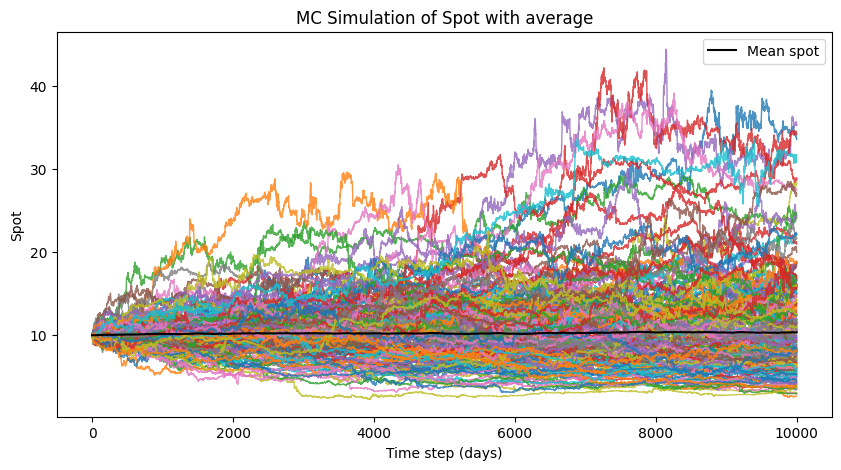

In [6]:
plt.figure(figsize=(10, 5))
for k in range(8, 190):
    plt.plot(S[:, k], linewidth = 1, alpha = 0.8)

mean_spot = np.mean(S, axis = 1)
plt.plot(mean_spot, "-", color = 'k', label = "Mean spot")
plt.xlabel("Time step (days)")
plt.ylabel("Spot")
plt.title("MC Simulation of Spot with average")
plt.legend()

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_2712/1443507488.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


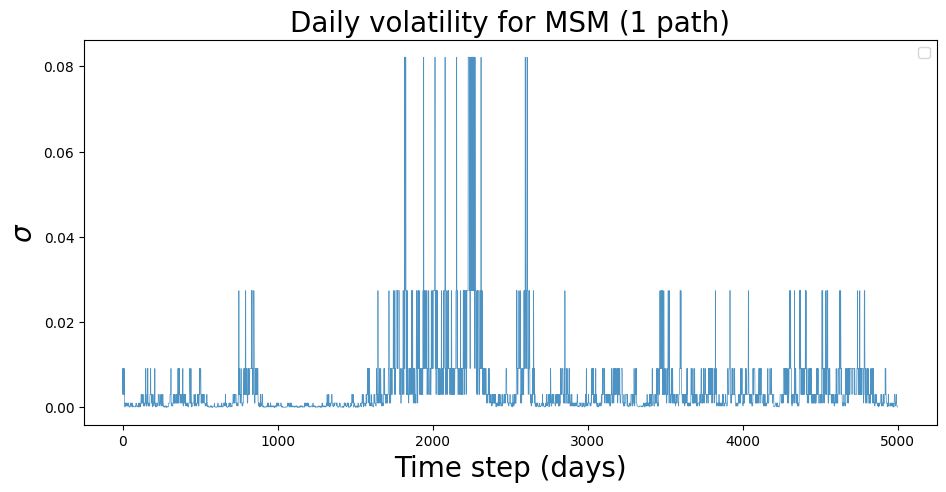

In [24]:
plt.figure(figsize=(11, 5))
plt.plot(np.sqrt(h[5000:, 0]), linewidth = 0.5, alpha = 0.8, color = 'tab:blue')
plt.xlabel("Time step (days)", fontsize = 20)
plt.ylabel(r"$\sigma$", fontsize = 20)
plt.title("Daily volatility for MSM (1 path)", fontsize = 20)
#plt.savefig("/Users/alexvillamartin/Documents/MSc Diss/Plots/daily_vol_msm")
plt.legend()

## Fat tails, long memeroy, clustering

In [7]:
def compute_acf(x, lags):
    x_mean = x.mean()
    y = x - x_mean

    acf_vals = np.zeros(lags)
    acf_vals[0] = 1.0
    for i in range(1, lags):

        acf_vals[i] = (np.dot(y[i:], y[:-i])) / np.dot(y, y)

    return acf_vals

def get_confd_bands(n_obs, acfs, alpha = 0.05):
    '''
    Assuming underlying process is MA(q) we use this.
    '''


    K = len(acfs)
    z = norm.ppf(1 - alpha/2)
    lower = np.zeros(K)
    upper = np.zeros(K)

    for h in range(1, K):
        var_h = (1 + 2*np.sum(acfs[1:h]**2)) / n_obs
        halfwidth = z * np.sqrt(var_h)
        lower[h] = -halfwidth
        upper[h] =  halfwidth

    return lower, upper

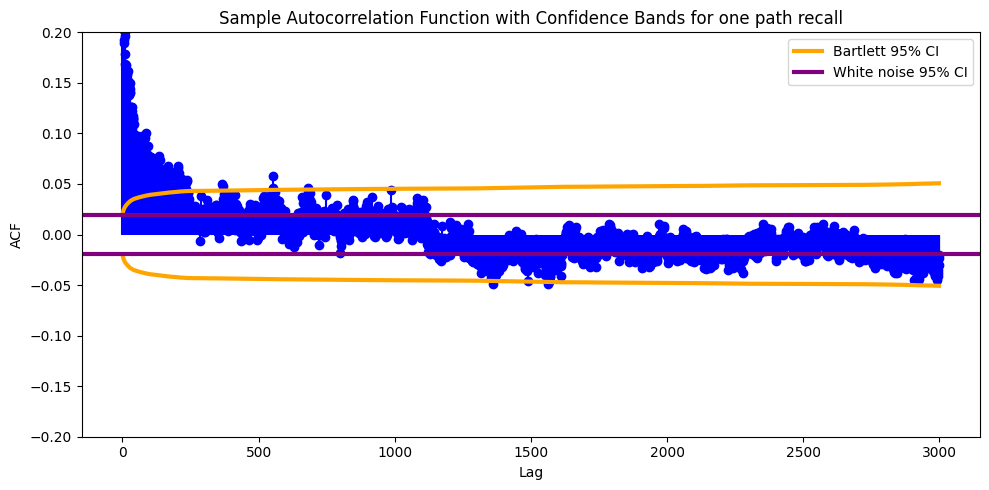

In [8]:
lags = 3000
x = abs(r[:, 5])
n_obs = len(x)

acf_vals = compute_acf(x, lags)
lo, up = get_confd_bands(n_obs, acf_vals)

other = 1.96 / np.sqrt(n_obs)

plt.figure(figsize=(10, 5))
plt.stem(range(0, lags), acf_vals[0:], linefmt='b-', markerfmt='bo', basefmt=' ')
plt.plot(up[1:], '-',color = 'orange', linewidth = 3,  label = "Bartlett 95% CI")
plt.plot(lo[1:], "-", color = "orange", linewidth = 3)
plt.axhline(y = other, color = "purple", linewidth = 3, label = "White noise 95% CI")
plt.axhline(y = -other, color = "purple", linewidth = 3)
plt.ylim([-0.2, 0.2])
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.title('Sample Autocorrelation Function with Confidence Bands for one path recall')
plt.tight_layout()
plt.legend()
plt.show()

Vol clustering is apparent from the significnace ACF values at short lags however, for this particualr path the clear long memery like in FIGARCH is not as apparent so we will ensure to do hurst analysis. 

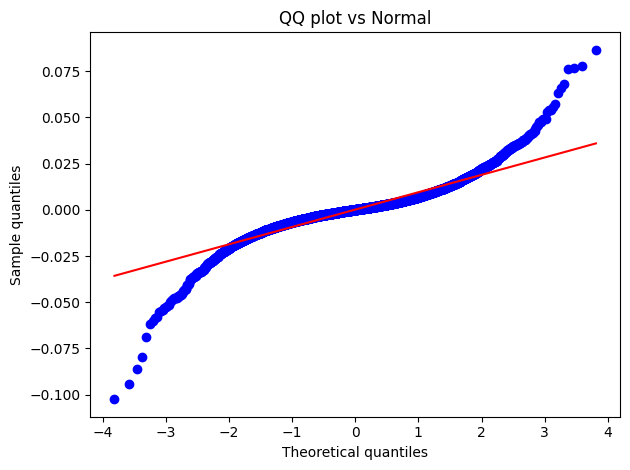

In [9]:
X = r[:, 0]  

stats.probplot(X, dist="norm", plot=plt)
plt.title("QQ plot vs Normal")
plt.xlabel("Theoretical quantiles")
plt.ylabel("Sample quantiles")
plt.tight_layout()
plt.show()

Fat tails. 

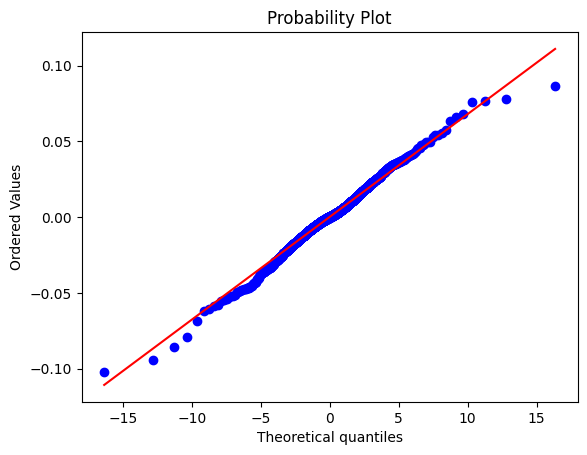

In [10]:
df_guess = 3.7
stats.probplot(X, dist=stats.t, sparams=(df_guess,), plot=plt)
plt.show()

In [11]:
Exkurts = np.zeros(npaths)
for i in range(npaths):
    Exkurts[i] = kurtosis(r[:, i], fisher=True) 

print(f"Mean excess kurt over {npaths} paths: {Exkurts.mean()}")

Mean excess kurt over 500 paths: 10.062256276284108


In [12]:
# as mentioned vol clustering will present itself as autocorreltaions at short lags
lags = 10

ps = []

for i in range(npaths):

    res = acorr_ljungbox(abs(r[:, i]), lags = lags, return_df=True)
    ps.append(res['lb_pvalue'].iloc[-1])

print(f"Mean p-value of Ljung Box test: {np.mean(ps)}")

bonf_corr = 0.01 / npaths
print(f"Bonf Corr: {bonf_corr}")

Mean p-value of Ljung Box test: 0.0
Bonf Corr: 2e-05


In [13]:
fisher_p   = combine_pvalues(ps, method='fisher')[1]
fisher_p

/Users/alexvillamartin/Documents/MSc Diss/Code/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:8980: RuntimeWarning: divide by zero encountered in log
  statistic = -2 * xp.sum(xp.log(pvalues), axis=axis)


np.float64(0.0)

In [14]:
from MFDFA_functions import get_moment_fluctuations_q, get_generalised_hurst, get_mf_spectrum, get_moment_fluctuations_q_kalman

In [15]:
def get_hurst(data):
    '''
    Use my MF-DFA functions to get hurst exponent only.
    '''

    X = data
    N = len(X)
    s_min = 10
    s_max = len(X) // 4
    q = 2 # reccomended in lit for between -6 and 6
    m= 1
    steps = 40
    mu_X = np.mean(X)
    Y = np.cumsum(X - mu_X)

    F_q, ss, _, _, _ = get_moment_fluctuations_q(q=q, s_min=s_min, s_max = s_max, Y=Y, m=m, numb_ss = steps)

    H = get_generalised_hurst(F_q = F_q, ss = ss)

    return H


In [16]:
hursts_r = []
hursts_abs_r = []

for i in range(10):
    H_r = get_hurst(data = r[:, i])
    H_abs_r = get_hurst(data = abs(r[:, i]))
    hursts_r.append(H_r)
    hursts_abs_r.append(H_abs_r)    

In [17]:
print(f"Hurst average on returns: {np.mean(hursts_r)}")
print(f"Hurst average on absolute returns: {np.mean(hursts_abs_r)}")

Hurst average on returns: 0.48076507341518465
Hurst average on absolute returns: 0.8440402681650147


Hence long memory, persistence is clearly present.

# MF-DFA

Recall we do analysis on returns.

In [5]:
from MFDFA_functions import get_moment_fluctuations_q, get_generalised_hurst, get_mf_spectrum, get_moment_fluctuations_q_kalman

In [6]:
spot = S[:, 0]
X = r[:, 0]
N = len(X)


In [7]:
s_min = 10
s_max = len(X) // 4
qs = np.arange(-10, 11,1) # reccomended in lit for between -6 and 6
m= 1
steps = 40
mu_X = np.mean(X)
Y = np.cumsum(X - mu_X)

In [8]:
F_qs = list()
fitss1 = list()
fitss2 = list()

for q in qs: 

    F_q, ss, fits1, fits2, buffer = get_moment_fluctuations_q(q=q, s_min=s_min, s_max = s_max, Y=Y, m=m, numb_ss = steps)
    F_qs.append(F_q)
    
    if q == 2:
        
        fitss1.append(fits1)
        fitss2.append(fits2)

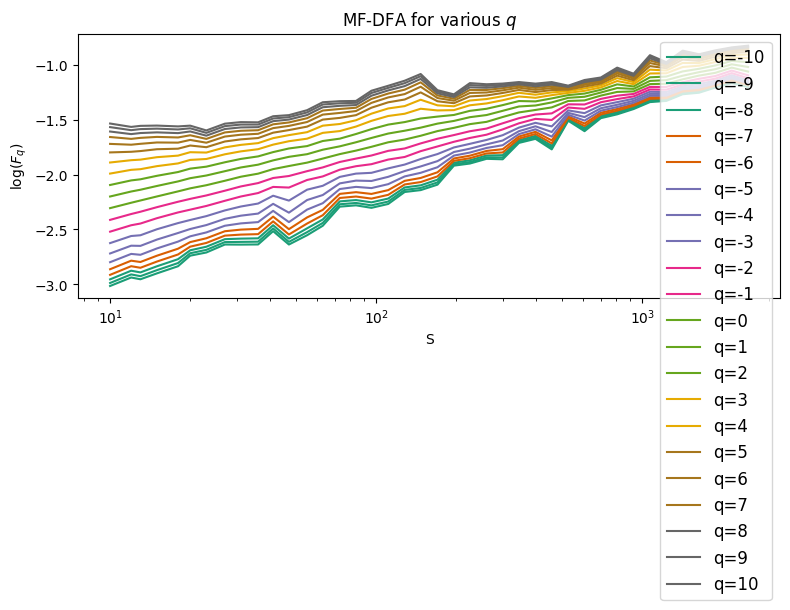

In [9]:
colors = plt.cm.Dark2(np.linspace(0, 1, len(qs)))

plt.figure(figsize = (8, 5))
for q_val, Fq, c in zip(qs, F_qs, colors):
    plt.plot((ss), np.log10(Fq), label=f'q={q_val}',  color = c, linewidth = 1.5)
plt.xscale('log')
plt.xlabel('S')
plt.ylabel(r'$\text{log}(F_q)$')
plt.title(r'MF-DFA for various $q$')
plt.legend(fontsize = "large")
plt.tight_layout()
plt.show()

Text(0.5, 0, 'Days')

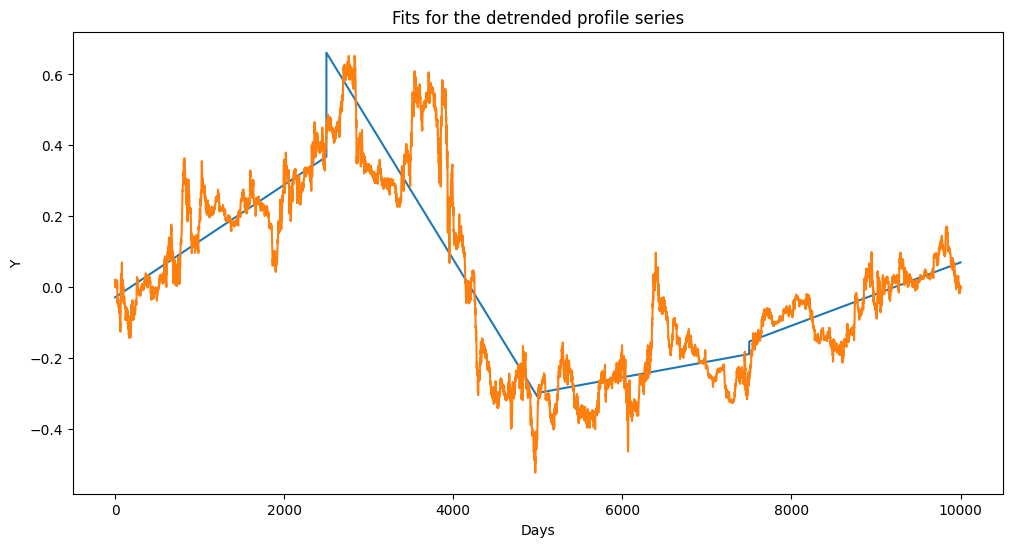

In [10]:
plt.figure(figsize = (12, 6))

y1 = np.concatenate(fitss1).flatten()
y2 = np.concatenate(fitss2).flatten()
t = np.arange(0, N, 1)
plt.plot(t, y1)
plt.plot(Y)
plt.title("Fits for the detrended profile series")
plt.ylabel("Y")
plt.xlabel("Days")

In [11]:
generalised_H = np.zeros(len(qs))

for i in range(len(F_qs)): 

    generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)

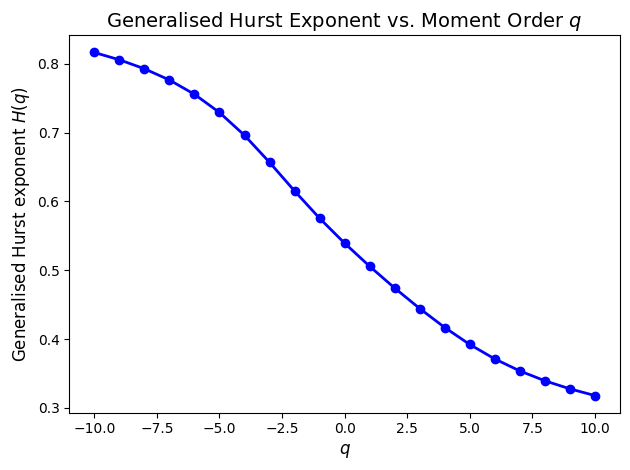

In [12]:
plt.plot(qs, generalised_H, linestyle='-', marker='o', markersize=6, linewidth=2, color='b')
plt.xlabel(r'$q$', fontsize=12)
plt.ylabel(r'Generalised Hurst exponent $H(q)$', fontsize=12)
plt.title(r'Generalised Hurst Exponent vs. Moment Order $q$', fontsize=14)
plt.tight_layout()
plt.show()

H(2) around 0.47 agrees with absence of long memory in return styalised fact. 

In [13]:
tao_q, alpha_q, f_alpha = get_mf_spectrum(generalised_H, qs)

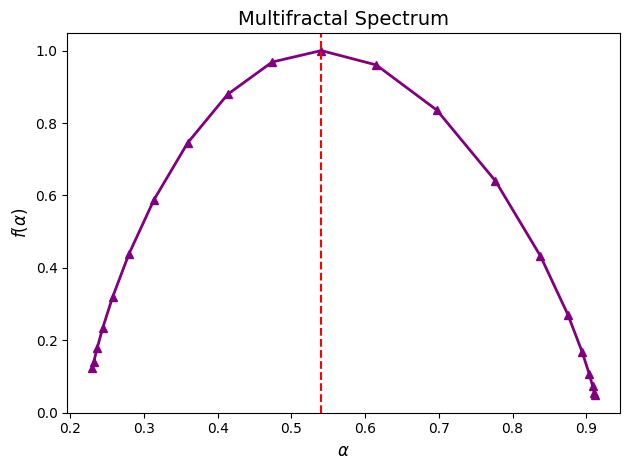

In [14]:
f_alpha_max_idx = np.argmax(f_alpha)

plt.plot(alpha_q, f_alpha, marker='^', markersize=6, linewidth=2, color='purple')
plt.xlabel(r'$\alpha$', fontsize=12)
plt.ylabel(r'$f(\alpha)$', fontsize=12)
plt.title(r'Multifractal Spectrum', fontsize=14)
plt.axvline(x=alpha_q[f_alpha_max_idx], color='red', linestyle='--', label='max f_alpha')
plt.tight_layout()
plt.show()

## compare to kalman-MF-DFA

In [ ]:
F_qs = list()

for q in qs: 

    F_q, ss, _, _, _ = get_moment_fluctuations_q_kalman(q=q, s_min=s_min, s_max = s_max, Y=Y, numb_ss = steps)
    F_qs.append(F_q)

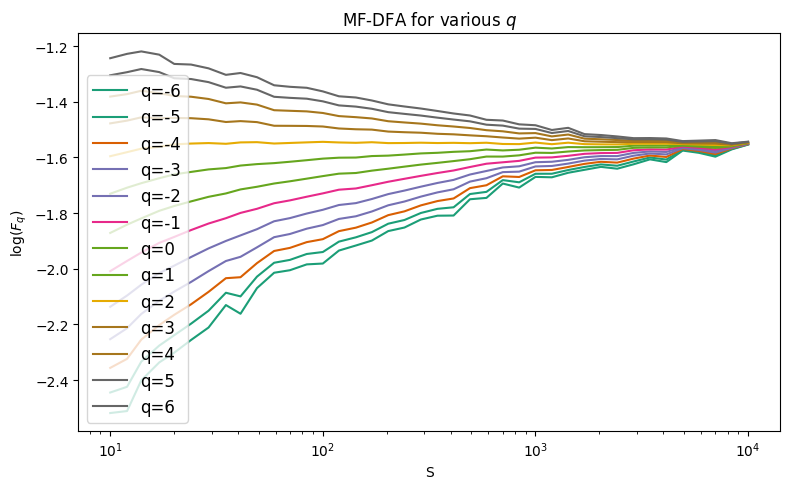

In [9]:
colors = plt.cm.Dark2(np.linspace(0, 1, len(qs)))

plt.figure(figsize = (8, 5))
for q_val, Fq, c in zip(qs, F_qs, colors):
    plt.plot((ss), np.log10(Fq), label=f'q={q_val}',  color = c, linewidth = 1.5)
plt.xscale('log')
plt.xlabel('S')
plt.ylabel(r'$\text{log}(F_q)$')
plt.title(r'MF-DFA for various $q$')
plt.legend(fontsize = "large")
plt.tight_layout()
plt.show()

In [10]:
generalised_H = np.zeros(len(qs))

for i in range(len(F_qs)): 

    generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)

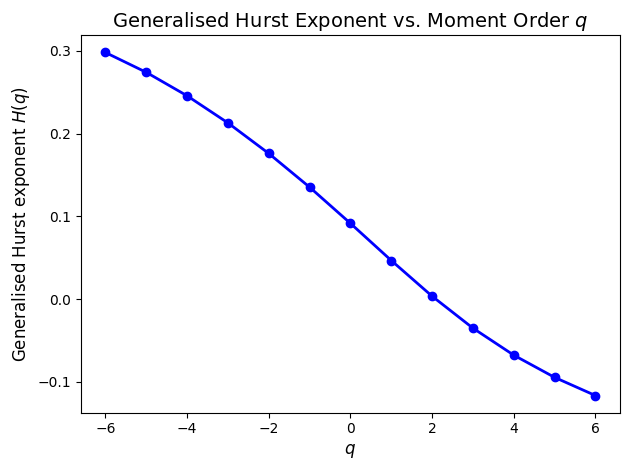

In [11]:
plt.plot(qs, generalised_H, linestyle='-', marker='o', markersize=6, linewidth=2, color='b')
plt.xlabel(r'$q$', fontsize=12)
plt.ylabel(r'Generalised Hurst exponent $H(q)$', fontsize=12)
plt.title(r'Generalised Hurst Exponent vs. Moment Order $q$', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
tao_q, alpha_q, f_alpha = get_mf_spectrum(generalised_H, qs)

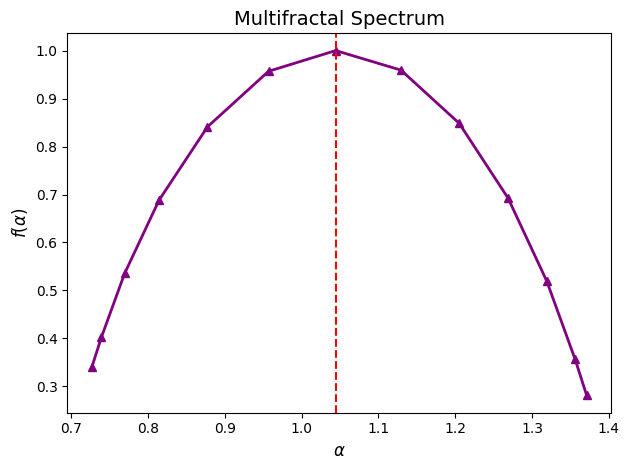

In [13]:
f_alpha_max_idx = np.argmax(f_alpha)

plt.plot(alpha_q, f_alpha, marker='^', markersize=6, linewidth=2, color='purple')
plt.xlabel(r'$\alpha$', fontsize=12)
plt.ylabel(r'$f(\alpha)$', fontsize=12)
plt.title(r'Multifractal Spectrum', fontsize=14)
plt.axvline(x=alpha_q[f_alpha_max_idx], color='red', linestyle='--', label='max f_alpha')
plt.tight_layout()
plt.show()

In [10]:
F_qs = list()
fitss1 = list()
fitss2 = list()
qs = [6]
for q in qs: 

    F_q, ss, fits1, fits2, buffer = get_moment_fluctuations_q_kalman(q=q, s_min=s_min, s_max = s_max, Y=Y, numb_ss = steps)
    F_qs.append(F_q)
    
    if q == 6:
        
        fitss1.append(fits1)
        fitss2.append(fits2)

Text(0.5, 0, 'Days')

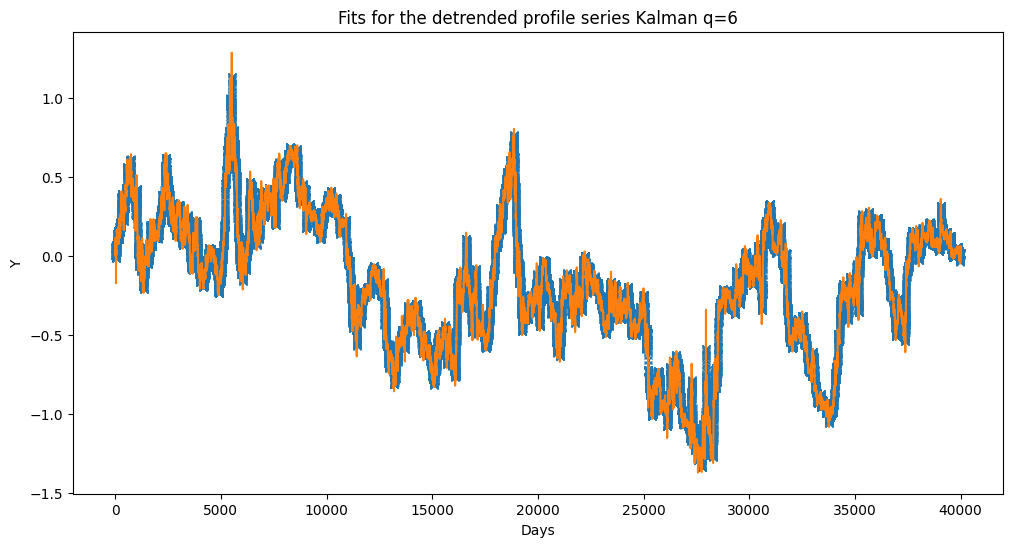

In [13]:
plt.figure(figsize = (12, 6))

y1 = np.concatenate(fitss1).flatten()
y2 = np.concatenate(fitss2).flatten()
t = np.arange(0, N, 1)
plt.plot(t, y1, 'x')
plt.plot(Y)
plt.title("Fits for the detrended profile series Kalman q=6")
plt.ylabel("Y")
plt.xlabel("Days")

We are removing too much of the fluctuations that we would like to measure thus this is not a sensible method.